#  Data Analytics Capstone - D502 

# Data Analytics Capstone: Predicting Hotel Booking Cancellations for Revenue Optimization

## Project Summary
This data analytics project aims to address the persistent challenge of perishable inventory in the hospitality industry by predicting hotel booking cancellations. When a room is canceled shortly before arrival, it results in unrecoverable revenue loss and operational inefficiency. By utilizing historical booking data, this project implements a supervised machine learning classification model (Random Forest Classifier) to identify high-risk bookings. The predictive insights generated by this model enable hotel management to confidently authorize strategic overbooking, proactively adjust non-refundable deposit policies, and optimize overall capacity management to maximize revenue.

## Dataset & Data Dictionary
The data used for this analysis is the "Hotel Booking Demand" dataset from Kaggle, containing 119,390 historical reservations for both city and resort hotels.

**Target Variable:**
* `is_canceled`: Value indicating if the booking was canceled (1) or not (0).

**Features:**
* `hotel`: Hotel type (Resort Hotel or City Hotel).
* `lead_time`: Number of days between the entering date of the booking and the arrival date.
* `arrival_date_year`: Year of arrival date.
* `arrival_date_month`: Month of arrival date.
* `arrival_date_week_number`: Week number of year for arrival date.
* `arrival_date_day_of_month`: Day of arrival date.
* `stays_in_weekend_nights`: Number of weekend nights (Saturday or Sunday) the guest stayed or booked to stay.
* `stays_in_week_nights`: Number of week nights (Monday to Friday) the guest stayed or booked to stay.
* `adults`: Number of adults.
* `children`: Number of children.
* `babies`: Number of babies.
* `meal`: Type of meal booked (e.g., Bed & Breakfast, Half board).
* `country`: Country of origin.
* `market_segment`: Market segment designation (e.g., Online Travel Agents, Corporate).
* `distribution_channel`: Booking distribution channel.
* `is_repeated_guest`: Value indicating if the booking name was from a repeated guest (1) or not (0).
* `previous_cancellations`: Number of previous bookings that were canceled by the customer.
* `previous_bookings_not_canceled`: Number of previous bookings not canceled by the customer.
* `reserved_room_type`: Code of room type reserved.
* `assigned_room_type`: Code for the type of room assigned to the booking. 
* `booking_changes`: Number of changes/amendments made to the booking.
* `deposit_type`: Indication on if the customer made a deposit to guarantee the booking (e.g., No Deposit, Non Refundable).
* `agent`: ID of the travel agency that made the booking.
* `company`: ID of the company/entity that made the booking or responsible for paying the booking.
* `days_in_waiting_list`: Number of days the booking was in the waiting list before it was confirmed.
* `customer_type`: Type of booking (e.g., Transient, Group).
* `adr`: Average Daily Rate.
* `required_car_parking_spaces`: Number of car parking spaces required by the customer.
* `total_of_special_requests`: Number of special requests made by the customer (e.g., twin bed, high floor).
* `reservation_status`: Reservation last status (Canceled, Check-Out, No-Show). *(Note: Dropped during preprocessing to prevent data leakage).*
* `reservation_status_date`: Date at which the last status was set. *(Note: Dropped during preprocessing to prevent data leakage).*

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-Learn modules for modeling and evaluation
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Set visualization style
sns.set_theme(style="whitegrid")

In [16]:
# Load the dataset
df = pd.read_csv(r'data/hotel_bookings.csv')

# Display basic information
print("Dataset Shape:", df.shape)
print("\nTarget Variable Distribution (is_canceled):")
print(df['is_canceled'].value_counts(normalize=True))

# Preview the first few rows
df.head()

Dataset Shape: (119390, 32)

Target Variable Distribution (is_canceled):
is_canceled
0    0.629584
1    0.370416
Name: proportion, dtype: float64


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [17]:
# Create a copy to avoid SettingWithCopy warnings
data = df.copy()

# 1. Handle Missing Values
# 'company' is mostly missing, 'agent' has some missing. We'll fill them with 0 (indicating none)
data['company'] = data['company'].fillna(0)
data['agent'] = data['agent'].fillna(0)
# 'country' has a few missing, fill with 'Unknown'
data['country'] = data['country'].fillna('Unknown')
# 'children' has a tiny amount of missing values, fill with 0
data['children'] = data['children'].fillna(0)

# 2. Drop Data Leakage Columns
# These columns are updated after the cancellation happens and will break the predictive model
cols_to_drop = ['reservation_status', 'reservation_status_date']
data = data.drop(columns=cols_to_drop)

# 3. Encode Categorical Variables
# Select all object (string) columns
categorical_cols = data.select_dtypes(include=['object', 'str']).columns

# Initialize LabelEncoder
le = LabelEncoder()

# Apply Label Encoding to categorical features
for col in categorical_cols:
    data[col] = le.fit_transform(data[col].astype(str))

print("Preprocessing complete. Current shape:", data.shape)

Preprocessing complete. Current shape: (119390, 30)


In [18]:
# Define features (X) and target (y)
X = data.drop('is_canceled', axis=1)
y = data['is_canceled']

# Split the data (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Initialize and train the Random Forest Classifier
# Using a set random_state for reproducibility
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

print("Model training complete.")

Model training complete.


Model Accuracy: 0.8942

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.94      0.92     15033
           1       0.89      0.82      0.85      8845

    accuracy                           0.89     23878
   macro avg       0.89      0.88      0.88     23878
weighted avg       0.89      0.89      0.89     23878



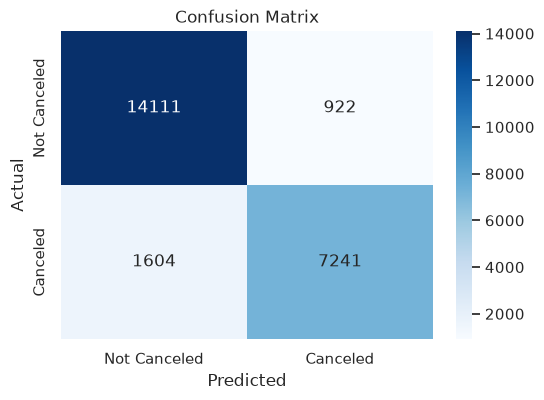

In [19]:
# Make predictions on the test set
y_pred = rf_model.predict(X_test)

# Calculate Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.4f}\n")

# Print Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Not Canceled', 'Canceled'], 
            yticklabels=['Not Canceled', 'Canceled'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

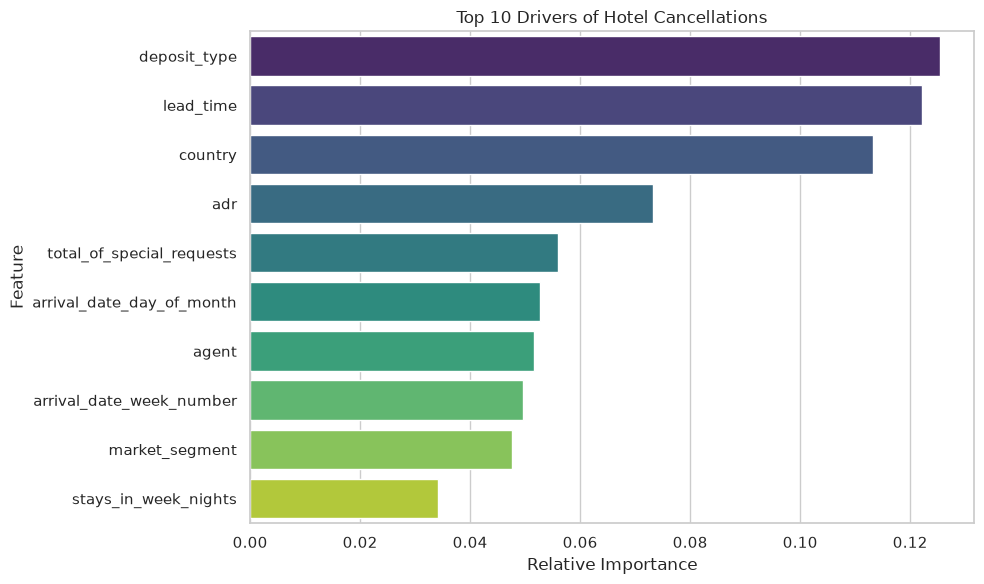

In [20]:
# Extract feature importances from the model
importances = rf_model.feature_importances_
feature_names = X.columns

# Create a DataFrame for visualization
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot the top 10 most important features
plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10), hue='Feature', palette='viridis', legend=False)
plt.title('Top 10 Drivers of Hotel Cancellations')
plt.xlabel('Relative Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

# Export cleaned data for Tableau usage later
# data.to_csv('cleaned_hotel_bookings_for_tableau.csv', index=False)